In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dalalyash","key":"9abef7ba2bafd17b9e557056a522d9f9"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!pip install kaggle

In [6]:
!kaggle datasets download -d tentotheminus9/gravity-spy-gravitational-waves

Dataset URL: https://www.kaggle.com/datasets/tentotheminus9/gravity-spy-gravitational-waves
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.89G/3.89G [02:57<00:00, 25.5MB/s]
100% 3.89G/3.89G [02:57<00:00, 23.5MB/s]


In [7]:
!unzip -q /content/gravity-spy-gravitational-waves.zip

In [8]:
'''
importing the required modules for the project
'''
import numpy as np
import pandas as pd

# plotting python modules
import matplotlib.pyplot as plt
import seaborn as sns

# modules helping to work with files and their paths
import os
import re

# modules for image processing
import cv2

# modules for creating neaural network pipelines
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

The folders in Gravity Spy are divided on the basis of their respective categories. Counting the number of subdirectories in the train folder would give the number of categories the images are divided into.

In [9]:
dir_path = r"/content/train/train"   # root directory declaration
folder_names = []         # list to append the names of individual categories
folder_count = 0         # count initialization to zero
'''
The below code works as -
It goes through each and every folder of the root directory. This gives the number of categories present using the count variable and also outputs a list containing all the
category names.
'''
for path in os.listdir(dir_path):
    if os.path.isdir(os.path.join(dir_path, path)):
        folder_count += 1
        folder_names.append(path)

print("The number of categories in Gravity Spy dataset: ", folder_count)
print("The categories are as: ", folder_names)

The number of categories in Gravity Spy dataset:  22
The categories are as:  ['Extremely_Loud', '1400Ripples', 'Whistle', 'None_of_the_Above', 'Low_Frequency_Lines', 'Scattered_Light', 'Tomte', '1080Lines', 'Light_Modulation', 'Paired_Doves', 'Scratchy', 'Violin_Mode', 'Helix', 'Blip', 'Wandering_Line', 'No_Glitch', 'Air_Compressor', 'Power_Line', 'Chirp', 'Koi_Fish', 'Low_Frequency_Burst', 'Repeating_Blips']


The following code gives the names of the categories and the number of images that are present in each of the categories in a cumulative format. To get the number of images in each category, subtract the previous number by the current number.

In [10]:
categories = []             # the list is same as folder_names as declared above but used for this particular use case
img_counter = 0                # universal counter that does not reset when the subfolder name changes.
subfolder_counter = []           # list declared to store the count after it encounters the last image in a particular category based folder
for name in range(len(folder_names)):
    subfolder_path = os.path.join(dir_path, folder_names[name])         # joins the root directory path with the name of the category
    categories.append(folder_names[name])
    for img in os.listdir(subfolder_path):
        if img.endswith(".png"):            # all images in this project are stored as png files, hence this condition has been defined to avoid files with non .png endings
            img_counter += 1
    subfolder_counter.append(img_counter)       # will store the counter value when the last image of a particular folder is encountered
print(subfolder_counter)
print(categories)

[1264, 1500, 2332, 2560, 3820, 5052, 5344, 6260, 7704, 7780, 8728, 9864, 10644, 15740, 15856, 16284, 16448, 17704, 17868, 19860, 21608, 22348]
['Extremely_Loud', '1400Ripples', 'Whistle', 'None_of_the_Above', 'Low_Frequency_Lines', 'Scattered_Light', 'Tomte', '1080Lines', 'Light_Modulation', 'Paired_Doves', 'Scratchy', 'Violin_Mode', 'Helix', 'Blip', 'Wandering_Line', 'No_Glitch', 'Air_Compressor', 'Power_Line', 'Chirp', 'Koi_Fish', 'Low_Frequency_Burst', 'Repeating_Blips']


In [11]:
'''
The following code subtracts the consecutive count values to give the number of images present in a particular category.
The number obtained after subtraction is stored in a list which will help to determine class imbalance.
'''
total_imgs = []
total_imgs.append(subfolder_counter[0])
for i in range(len(subfolder_counter)-1):
    sub = subfolder_counter[i+1] - subfolder_counter[i]
    total_imgs.append(sub)
print(total_imgs)
print(len(total_imgs))

[1264, 236, 832, 228, 1260, 1232, 292, 916, 1444, 76, 948, 1136, 780, 5096, 116, 428, 164, 1256, 164, 1992, 1748, 740]
22


Plotting information helps to assess the nuances in the data. Barplot would be a perfect fit in cases where the count of a certain category needs to be found. Visual representations also help to understand the differences in an easier manner.


The following plot depicts that the dataset is highly imbalanced with most number of images in **Blip** category. Which is more than twice the second placed **Koi_Fish** category, closely followed by **Low_Frequency_Burst**.

The least amount of images in a particular category can be found in **Paired_Doves, Wandering_Lines, Air_Compressor and Chirp**.

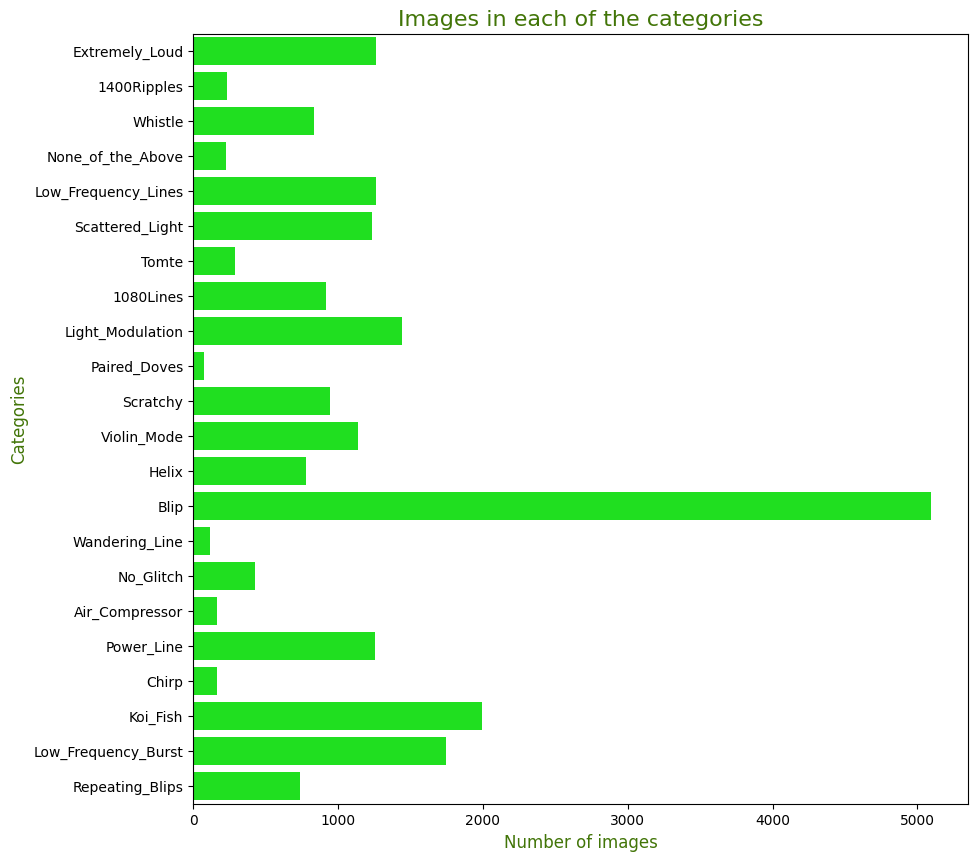

In [12]:
plt.figure(figsize=(10,10))
sns.barplot(x = total_imgs, y = categories, color = 'lime')
plt.title("Images in each of the categories", color = '#427508', fontsize = 16)
plt.xlabel("Number of images", color = '#427508', fontsize = 12)
plt.ylabel("Categories", color = '#427508', fontsize = 12)
plt.show()

In [13]:
# '''
# The code below calculates the shape of the image and checks whether the image shape is consistent across all the categorical folders and the images in them.

# Although this is a highly computative approach and consumes 5 minutes of time. It helps in determining the uniformity of shapes and helps to further analyze.

# The shape of the images is (479, 569, 4). The images are rectangular and not square.
# '''
# categories = []
# for name in range(len(folder_names)):
#     subfolder_path = os.path.join(dir_path, folder_names[name])
#     categories.append(folder_names[name])
#     for img in os.listdir(subfolder_path):
#         if img.endswith(".png"):
#             full_path = os.path.join(subfolder_path, img)
#             image = plt.imread(full_path)
#             if image.shape == (479, 569, 4):
#                 continue
#             else:
#                 print("Invalid Size")

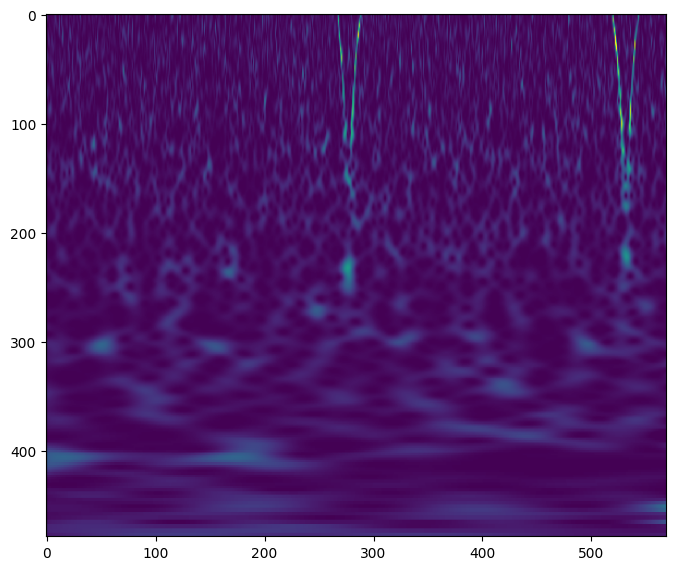

In [14]:
# visualizing an image to understand the image and then take decision of resizing the image for further preprocessing

plt.figure(figsize = (8,8))
image = plt.imread("/content/train/train/Whistle/L1_eZzhGjK5ck_spectrogram_2.0.png")
plt.imshow(image)

(384, 384, 4)


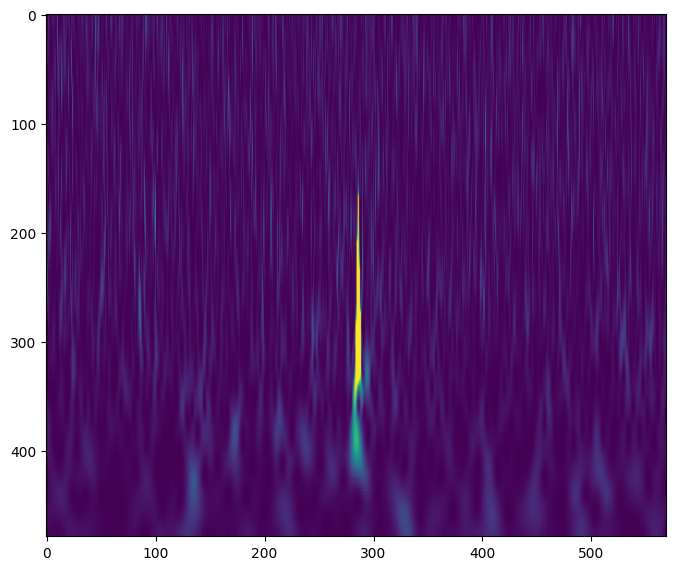

In [15]:
'''
Usually powers of 2 are selected as a number to resize the images, eg. 128, 256, 512.
In this case 512 would be larger and 256 would be smaller and could lead to loss of data. Hence 256 + 128 = 384 is selected as a number to reshape the image into.
'''
new_image = cv2.resize(image, (384, 384))
print(new_image.shape)
plt.figure(figsize = (8,8))
image = plt.imread("/content/train/train/Blip/H1_017BiNepgE_spectrogram_4.0.png")
plt.imshow(image)

In [16]:
train_dir_path = '/content/train/train'               # defining the main dir path

training_set = tf.keras.utils.image_dataset_from_directory(
    train_dir_path,
    labels = 'inferred',
    label_mode='int',
    color_mode = 'grayscale',
    batch_size = 64,
    image_size = (384,384),
    shuffle = True,
)

# for name in folder_names:                           # folder_names var considered from above cells which has the names of categories stored in it
#     subfolder_path = os.path.join(dir_path, name)         # joins the root directory path with the name of the category
#     # print(subfolder_path)
#     image_name = [img for img in os.listdir(subfolder_path) if img.endswith(".png")]
#     image_data = tf.data.Dataset.from_tensor_slices(image_name)

#     def resizing_image(image_path):
#         image = tf.io.read_file(image_path)
#         image = tf.image.decode_png(image, channels = 4)
#         image = tf.image.resize(image, [384, 384])
#         return image

#     image_data = image_data.map(resizing_image)

#     datasets.append(image_data)

Found 22348 files belonging to 22 classes.


In [17]:
val_dir_path = '/content/validation/validation'

validation_set = tf.keras.utils.image_dataset_from_directory(
    val_dir_path,
    labels = 'inferred',
    label_mode='int',
    color_mode = 'grayscale',
    batch_size = 64,
    image_size = (384,384),
    shuffle = True,
)

Found 4800 files belonging to 22 classes.


In [18]:
categories = training_set.class_names
print(categories)

['1080Lines', '1400Ripples', 'Air_Compressor', 'Blip', 'Chirp', 'Extremely_Loud', 'Helix', 'Koi_Fish', 'Light_Modulation', 'Low_Frequency_Burst', 'Low_Frequency_Lines', 'No_Glitch', 'None_of_the_Above', 'Paired_Doves', 'Power_Line', 'Repeating_Blips', 'Scattered_Light', 'Scratchy', 'Tomte', 'Violin_Mode', 'Wandering_Line', 'Whistle']


In [19]:
def normalization(image, label):
    image = tf.cast(image, tf.float16)/255.0
    return image, label

training_set = training_set.map(normalization)
validation_set = validation_set.map(normalization)

In [20]:
training_set

<_MapDataset element_spec=(TensorSpec(shape=(None, 384, 384, 1), dtype=tf.float16, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [21]:
validation_set

<_MapDataset element_spec=(TensorSpec(shape=(None, 384, 384, 1), dtype=tf.float16, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [23]:
num_classes = len(categories)

model = Sequential([
    Conv2D(filters=32, kernel_size=(5,5), input_shape=(384,384,1), activation='relu'),
    MaxPooling2D((2,2)),
    layers.Dropout(0.2),
    Conv2D(filters=16, kernel_size=(5,5), activation='relu'),
    MaxPooling2D((2,2)),
    layers.Dropout(0.2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

In [24]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [25]:
model.build(input_shape = (384,384,1))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 380, 380, 32)      832       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 190, 190, 32)      0         
 g2D)                                                            
                                                                 
 dropout_2 (Dropout)         (None, 190, 190, 32)      0         
                                                                 
 conv2d_3 (Conv2D)           (None, 186, 186, 16)      12816     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 93, 93, 16)        0         
 g2D)                                                            
                                                                 
 dropout_3 (Dropout)         (None, 93, 93, 16)       

In [26]:
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.005,
    restore_best_weights=True
)

In [28]:
history = model.fit(
    training_set,
    epochs=5,
    validation_data=validation_set,
    callbacks=[early_stopping_callback]
)

Epoch 1/5
350/350 [==============================] - 229s 642ms/step - loss: 0.0683 - accuracy: 0.9819 - val_loss: 0.4035 - val_accuracy: 0.9250
Epoch 2/5
350/350 [==============================] - 229s 645ms/step - loss: 0.0570 - accuracy: 0.9851 - val_loss: 0.4239 - val_accuracy: 0.9279
Epoch 3/5
350/350 [==============================] - 228s 643ms/step - loss: 0.0472 - accuracy: 0.9880 - val_loss: 0.4323 - val_accuracy: 0.9217
Epoch 4/5
350/350 [==============================] - 230s 649ms/step - loss: 0.0403 - accuracy: 0.9894 - val_loss: 0.5241 - val_accuracy: 0.9187
Epoch 5/5
350/350 [==============================] - 234s 660ms/step - loss: 0.0454 - accuracy: 0.9886 - val_loss: 0.4470 - val_accuracy: 0.9242


In [43]:
loss_vals = np.round(history.history["loss"],4)
loss_vals = list(loss_vals)
val_loss_vals = np.round(history.history["val_loss"],4)
val_loss_vals = list(val_loss_vals)
acc_vals = np.round(history.history["accuracy"],4)
acc_vals = list(acc_vals)
val_acc_vals = np.round(history.history["val_accuracy"],4)
val_acc_vals = list(val_acc_vals)
print(loss_vals, acc_vals, val_loss_vals, val_acc_vals)

[0.0683, 0.057, 0.0472, 0.0403, 0.0454] [0.9819, 0.9851, 0.988, 0.9894, 0.9886] [0.4035, 0.4239, 0.4323, 0.5241, 0.447] [0.925, 0.9279, 0.9217, 0.9187, 0.9242]


<Figure size 800x800 with 0 Axes>

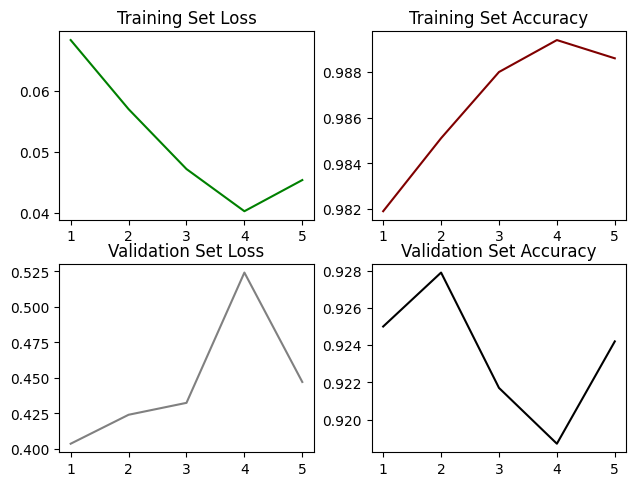

In [51]:
epochs = []
for i in range(1,6):
    epochs.append(i)
plt.figure(figsize = (8,8))
fig, axs = plt.subplots(2,2)
fig.tight_layout()
axs[0,0].plot(epochs, loss_vals, color = 'green')
axs[0,1].plot(epochs, acc_vals, color = 'maroon')
axs[1,0].plot(epochs, val_loss_vals, color = 'gray')
axs[1,1].plot(epochs, val_acc_vals, color = 'k')
axs[0,0].set_title("Training Set Loss")
axs[0,1].set_title("Training Set Accuracy")
axs[1,0].set_title("Validation Set Loss")
axs[1,1].set_title("Validation Set Accuracy")
plt.show()